## Load packages and define functions

In [1]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

<IPython.core.display.Javascript object>

In [2]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [3]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

IKEA_ISOS.sort()

## Load data

In [4]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [5]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [6]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [7]:
input_data = pyam.IamDataFrame(REMIND_PATH / 'ar6_templates/REMIND-MAgPIE_coreAndVariations_2025-12-10_16.07.26.xlsx')

pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP1 - Updating global 1.5°C Pathways/1 - PIK/Scenario Data/SUBMITTED_SCENARIOS_August2025/ar6_templates/REMIND-MAgPIE_coreAndVariations_2025-12-10_16.07.26.xlsx


In [123]:
input_data_harm = pyam.IamDataFrame(REMIND_PATH / 'processed_data/npe_core_scenario_harmonised_AR6_reporting.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP1 - Updating global 1.5°C Pathways/1 - PIK/Scenario Data/SUBMITTED_SCENARIOS_August2025/processed_data/npe_core_scenario_harmonised_AR6_reporting.csv


In [124]:
input_data_harm

<class 'pyam.core.IamDataFrame'>
Index:
 * model    : REMIND 3.4 (1)
 * scenario : NPE-core (1)
Timeseries data coordinates:
   region   : CAZ, CHA, EUR, IND, JPN, LAM, MEA, NEU, OAS, REF, ... World (13)
   variable : Capacity Additions|Electricity|Biomass, ... (570)
   unit     : %, EJ/yr, GW, GW/yr, GWh/yr, Index (2020 = 1), ... million vehicles (41)
   year     : 2005, 2010, 2011, 2012, 2013, 2014, 2015, 2016, ... 2100 (26)
Meta indicators:
   exclude (bool) False (1)

In [8]:
primap_data = dt.findp(source = "PRIMAP_2025").as_pyam()

In [9]:
hist_data = pyam.IamDataFrame(DSCALE_PATH /  'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv


In [10]:
dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/results_harmo_AR6_template/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2026_01_21_2022_harmo_step5e_None.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/outputs/results_harmo_AR6_template/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2026_01_21_2022_harmo_step5e_None.csv


In [11]:
mdps_remind = pd.read_csv('/Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/CAT in CPT folder/05_Domestic Emission Pathways/MDP data/results/20251219_PIK|CA_AR5GWP100_2023-MDP/PIK|CA_downscaled_total.csv',
index_col = [0,1,2,3,4])

In [12]:
mdps_remind.index.names = ['model', 'scenario', 'unit', 'region', 'variable']

In [13]:
mdps_remind=pyam.IamDataFrame(mdps_remind)

In [118]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}

REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')
REMIND_RMAP

def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return df_region

In [119]:
macro_df = create_macro_df(dscale_results)

# PLOTTING DATA

In [15]:
dscale_emissions = dscale_results.filter(variable = "Emissions*")

In [16]:
dscale_emissions.filter(variable = ["*Transport*", "*Indust*", "*Residen*"], region = IKEA_ISOS).variable

['Emissions|CO2|Energy|Demand|Industry',
 'Emissions|CO2|Energy|Demand|Residential and Commercial',
 'Emissions|CO2|Industrial Processes',
 'Emissions|CO2|Energy|Demand|Transportation']

In [39]:
import data_shepherd as ds
from data_shepherd import emissions, energy_forms

In [37]:
primap_data = emissions.get_historic_primap(
        # gases=config.gases, 
        # sectors = []
        source="PRIMAP_2025", 
        # scenario="Historic|country_reported", 
        context="AR5GWP100" 
)

In [41]:
iea_co2_data = emissions.get_historic_iea(source = "IEA_GHG_FUEL_DETAILED_2024")

data_shepherd.emissions - WARNING: Using Energy|Supply|Electricity and Heat timeseries for Electricity for ALB, NPL


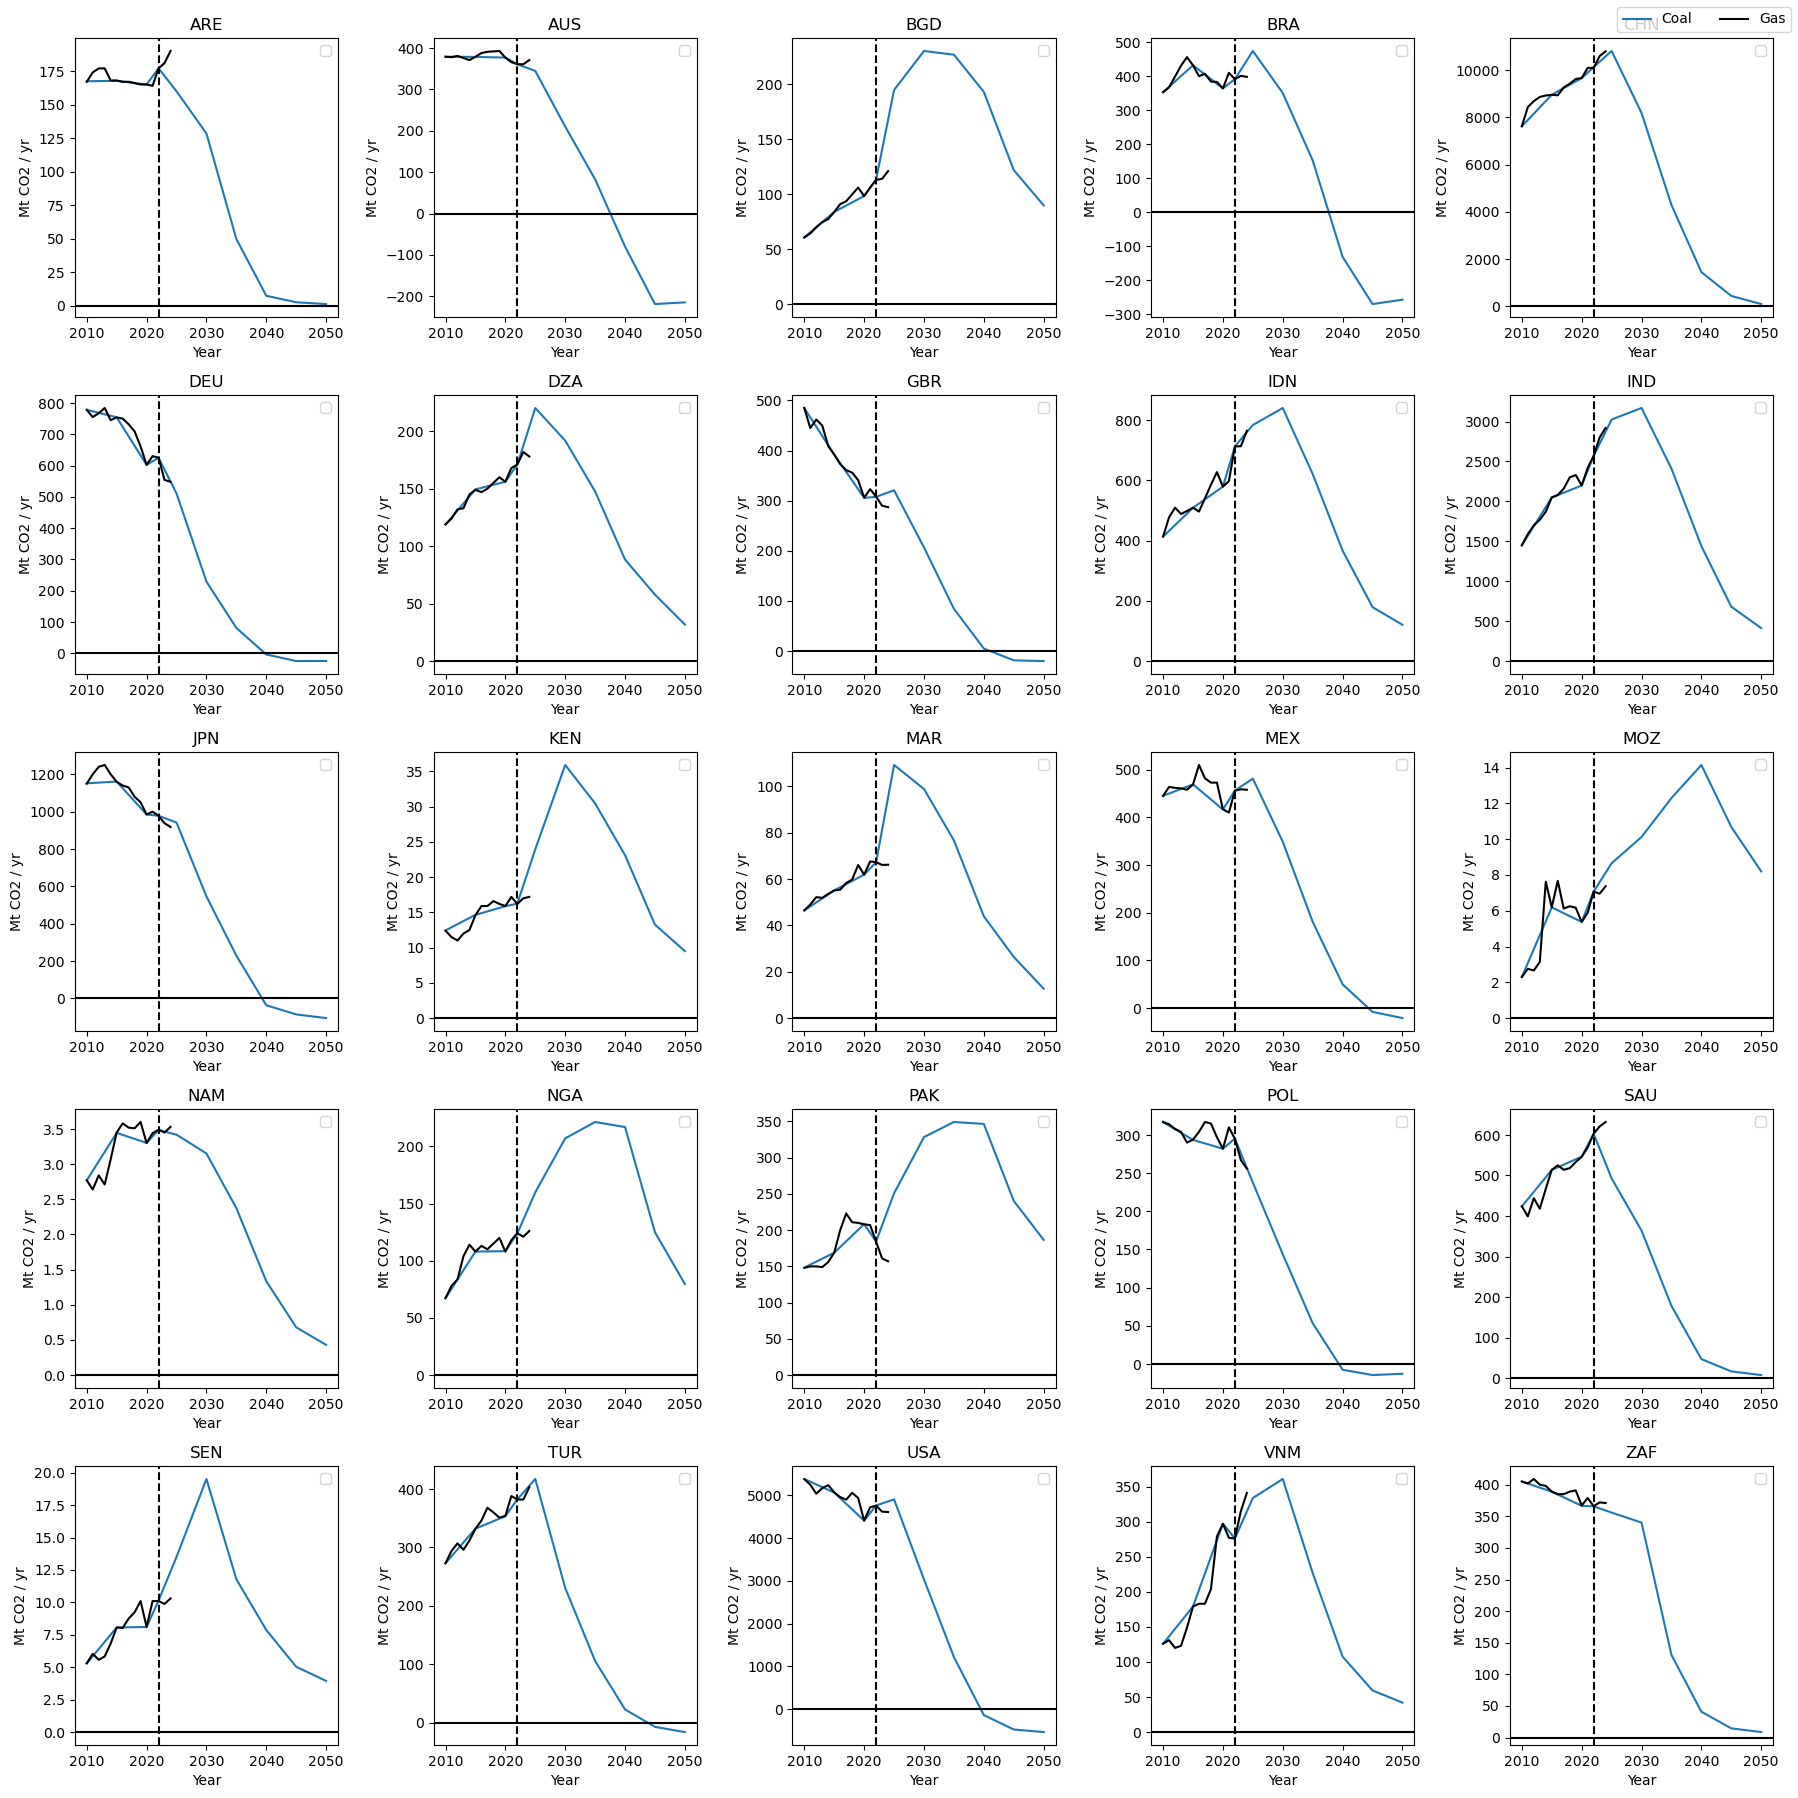

In [68]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


# f.suptitle('Coal and gas power sector transition',fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

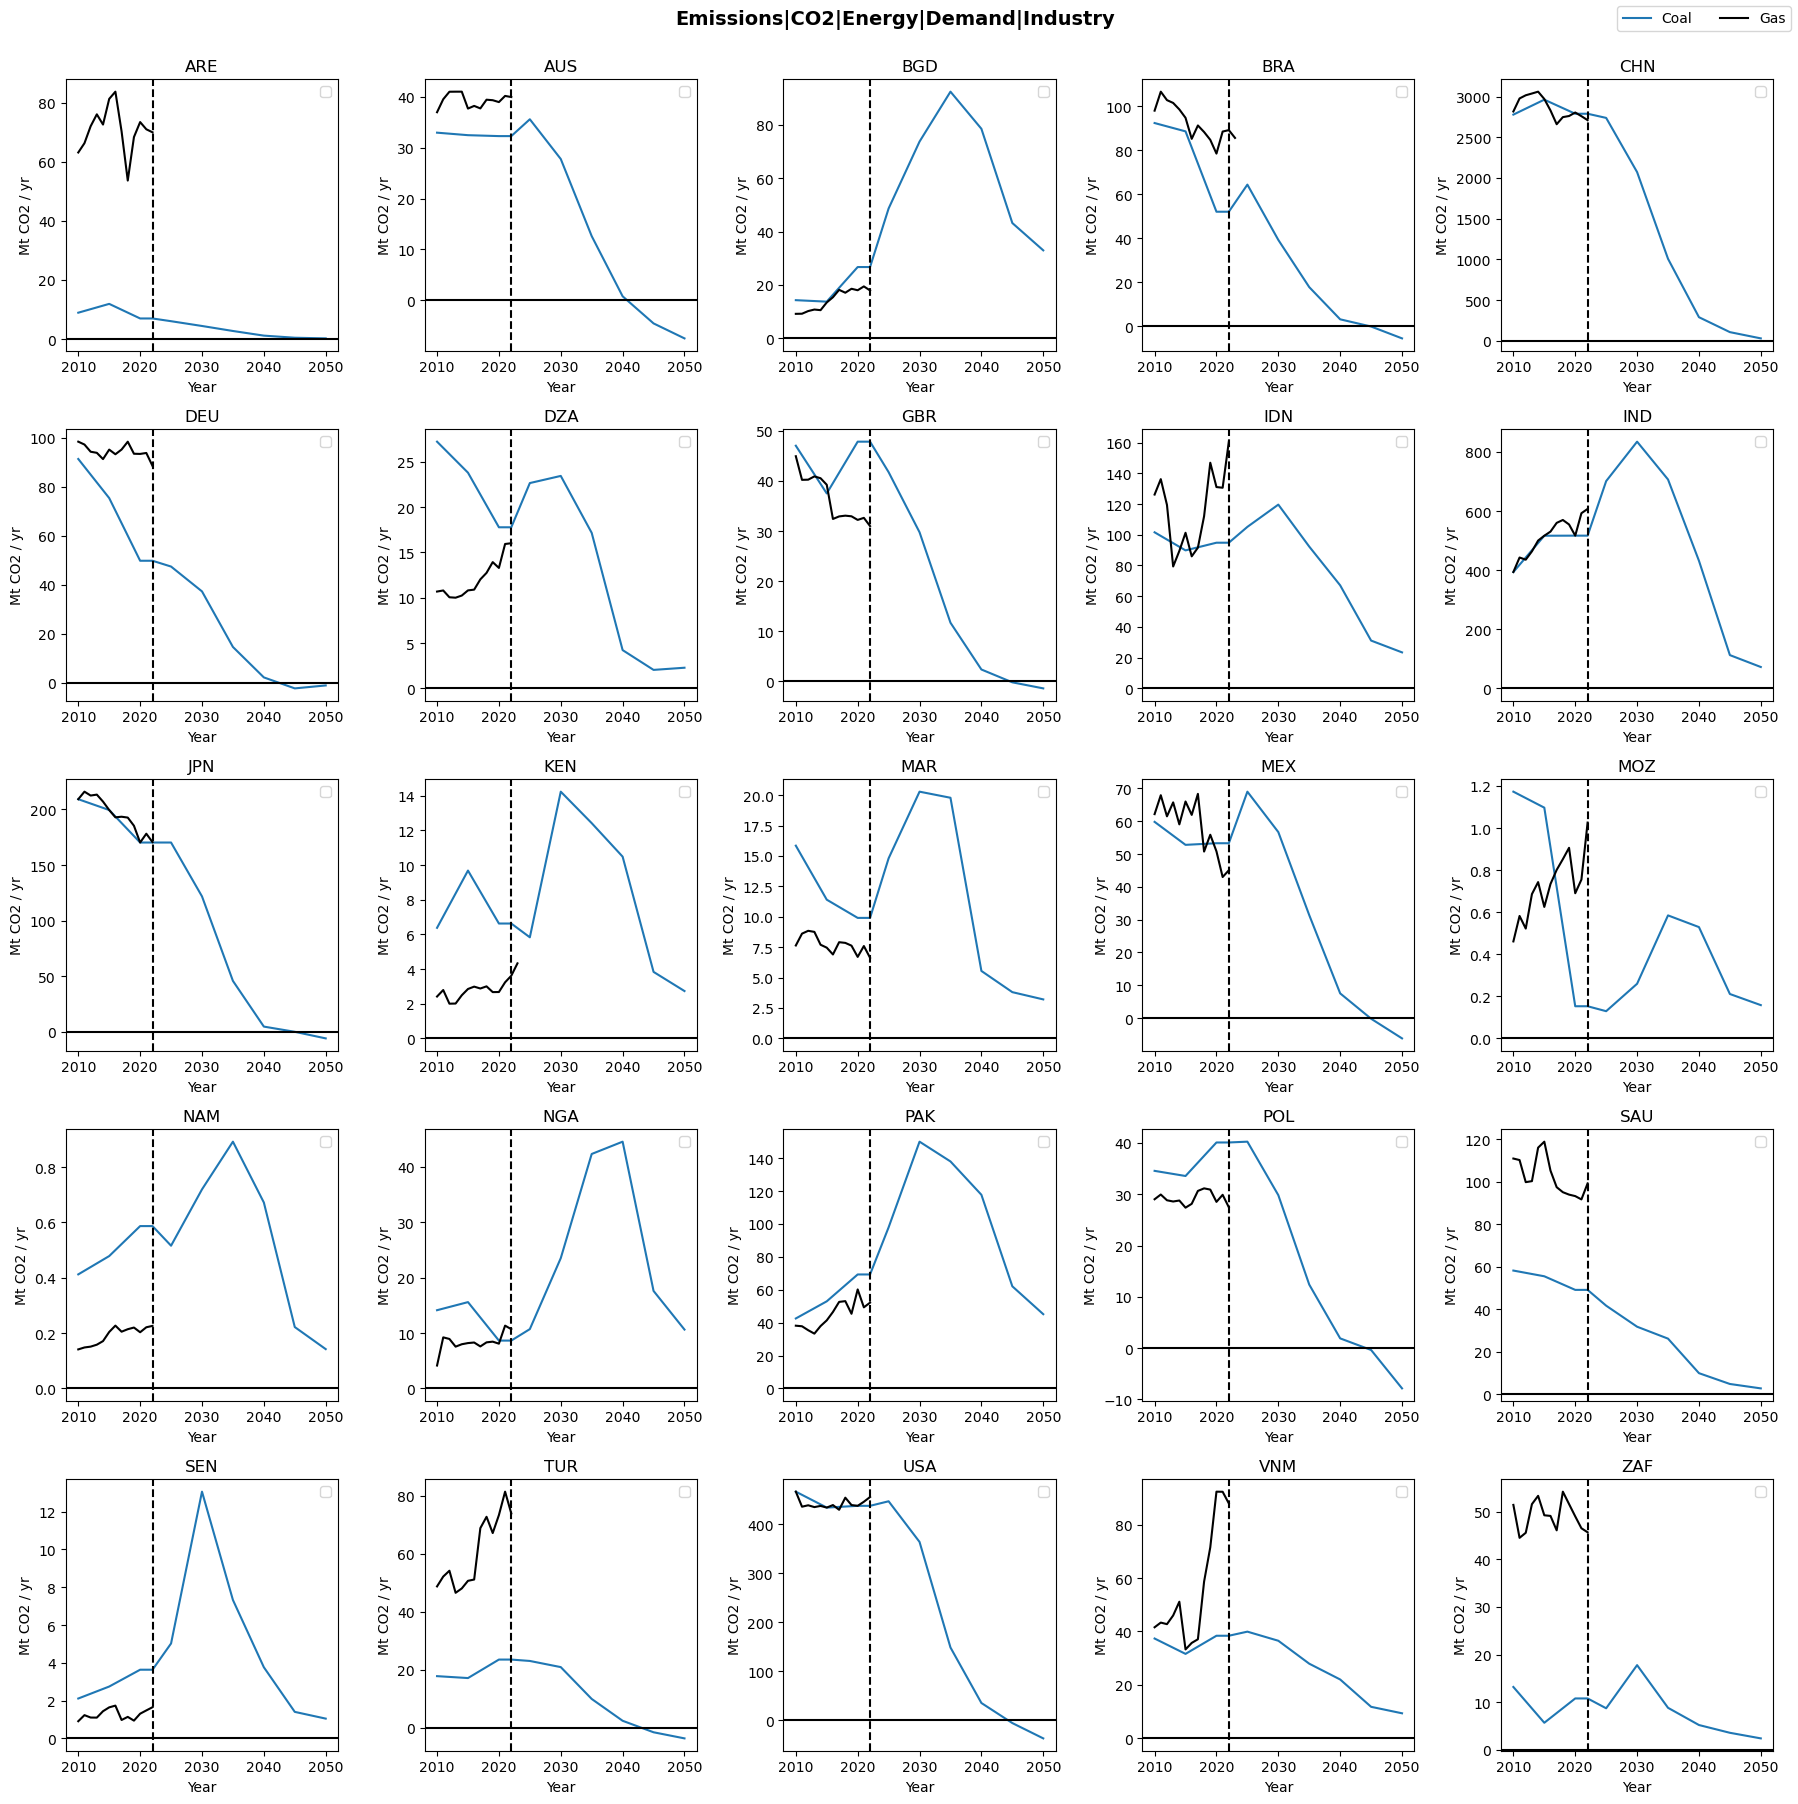

In [74]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy|Demand|Industry"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    iea_co2_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

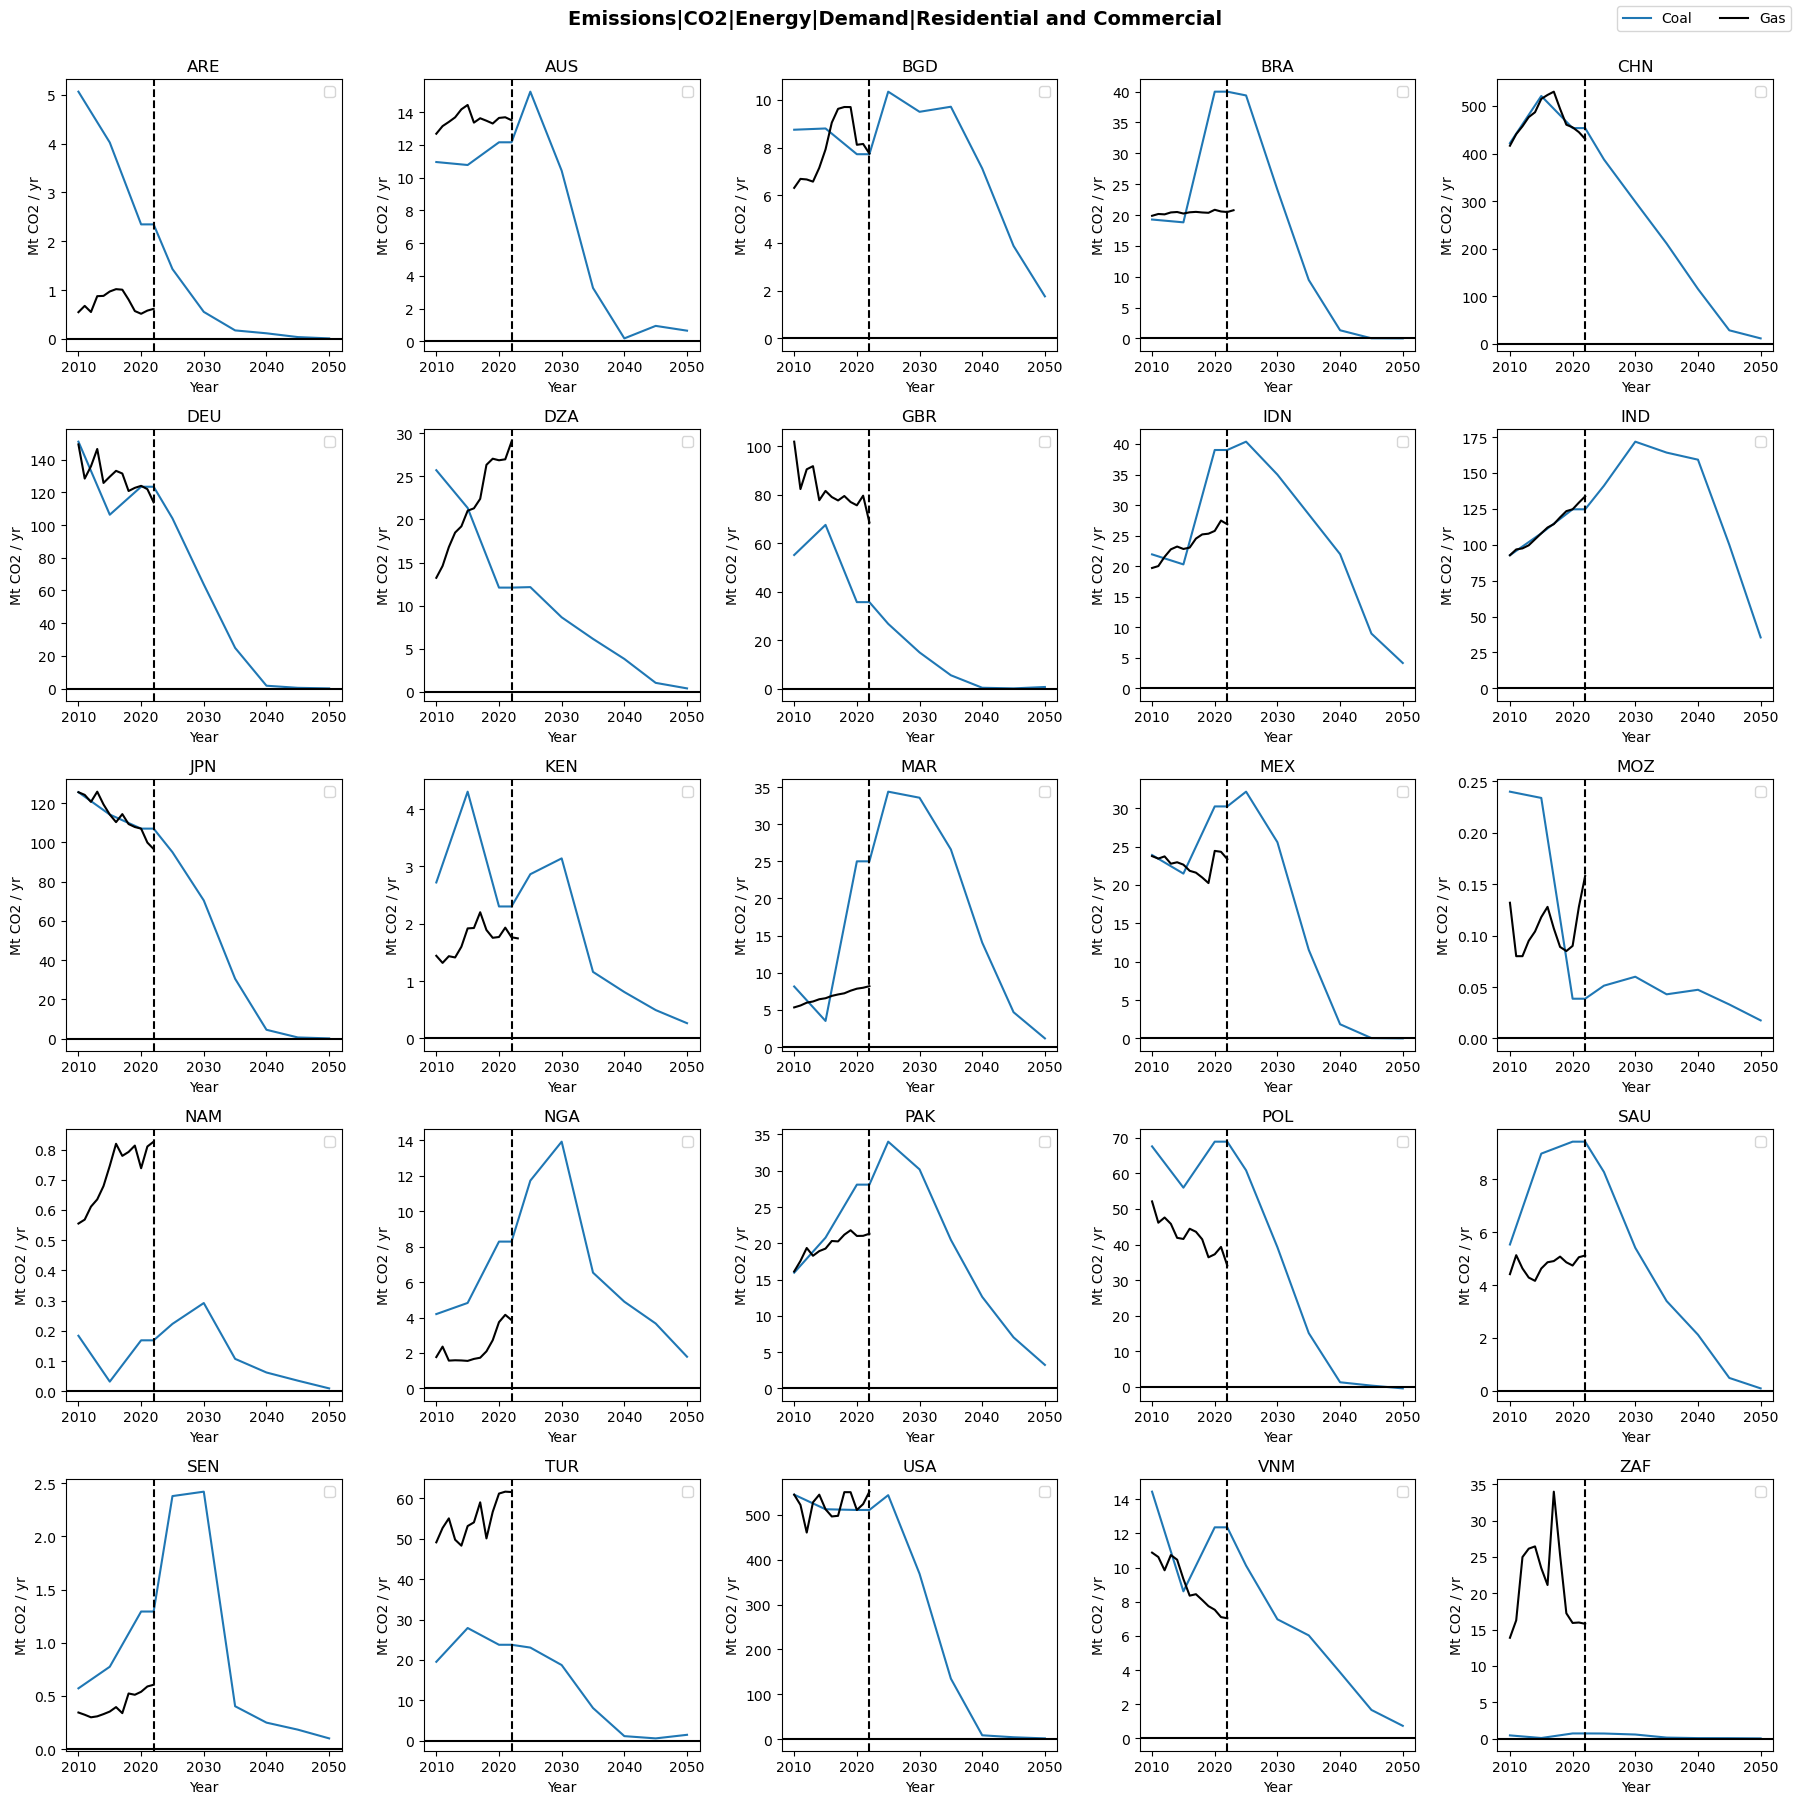

In [73]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy|Demand|Residential and Commercial"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    iea_co2_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is 

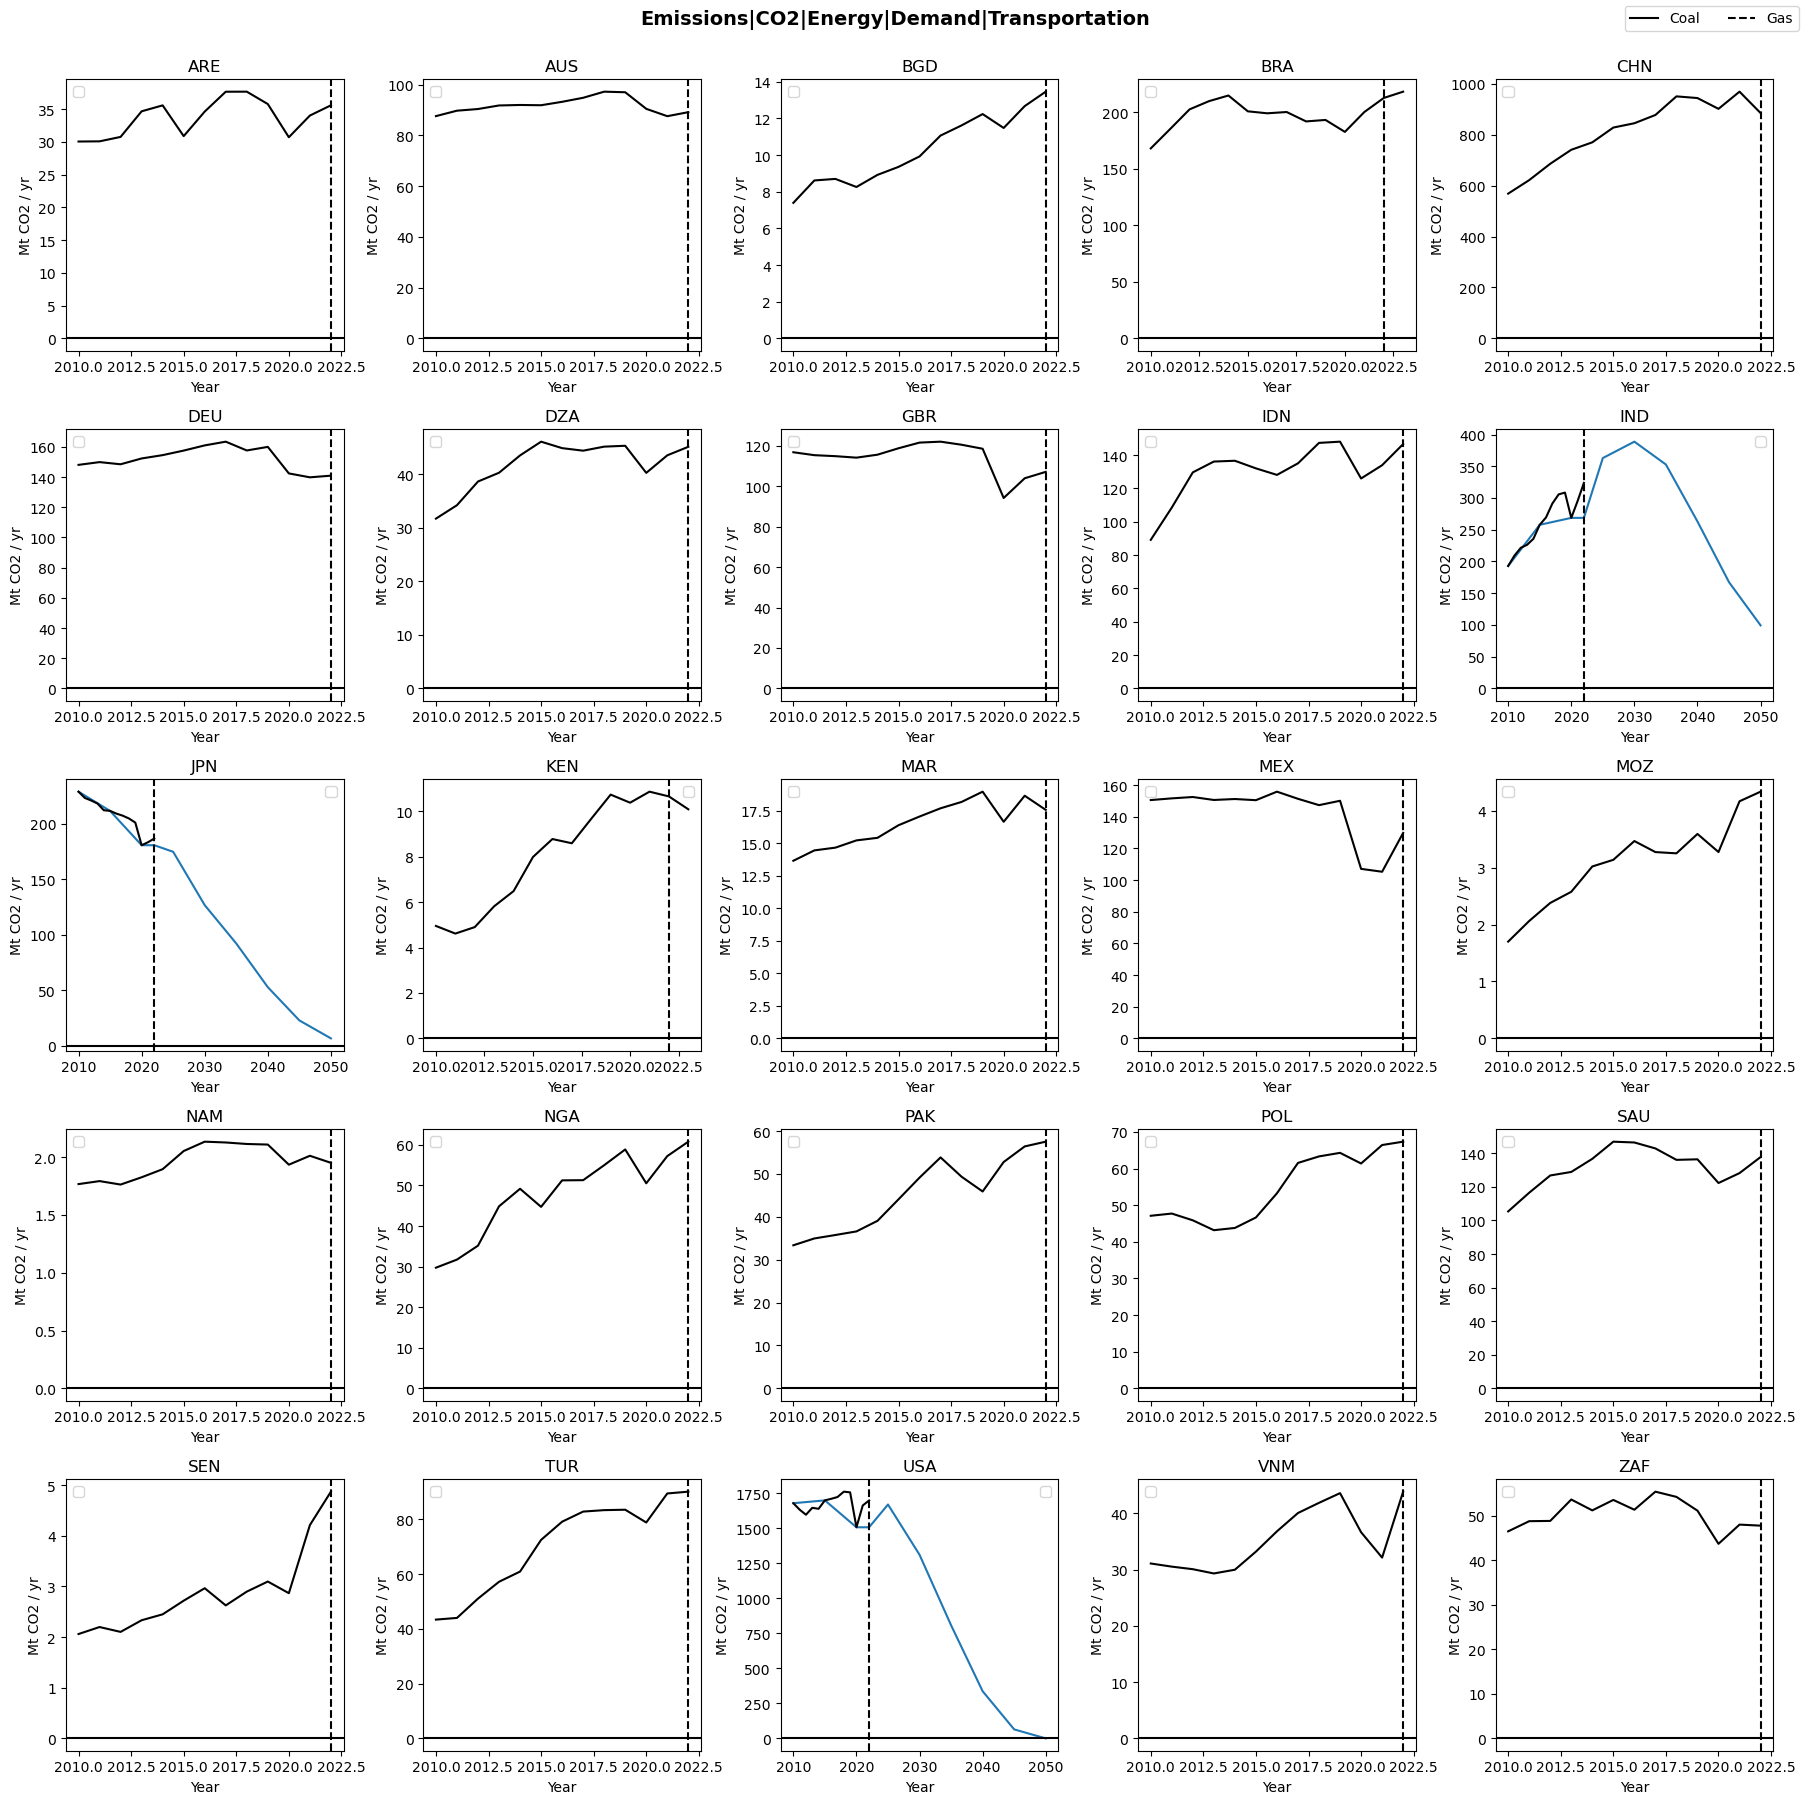

In [72]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy|Demand|Transportation"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    iea_co2_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

# Consistency check

In [71]:
dscale_emissions.filter(variable = "Emissions|CO2|Energy*").variable

['Emissions|CO2|Energy',
 'Emissions|CO2|Energy|Demand|Industry',
 'Emissions|CO2|Energy|Demand|Residential and Commercial',
 'Emissions|CO2|Energy|Supply|Electricity|Oil',
 'Emissions|CO2|Energy|Demand|Transportation']

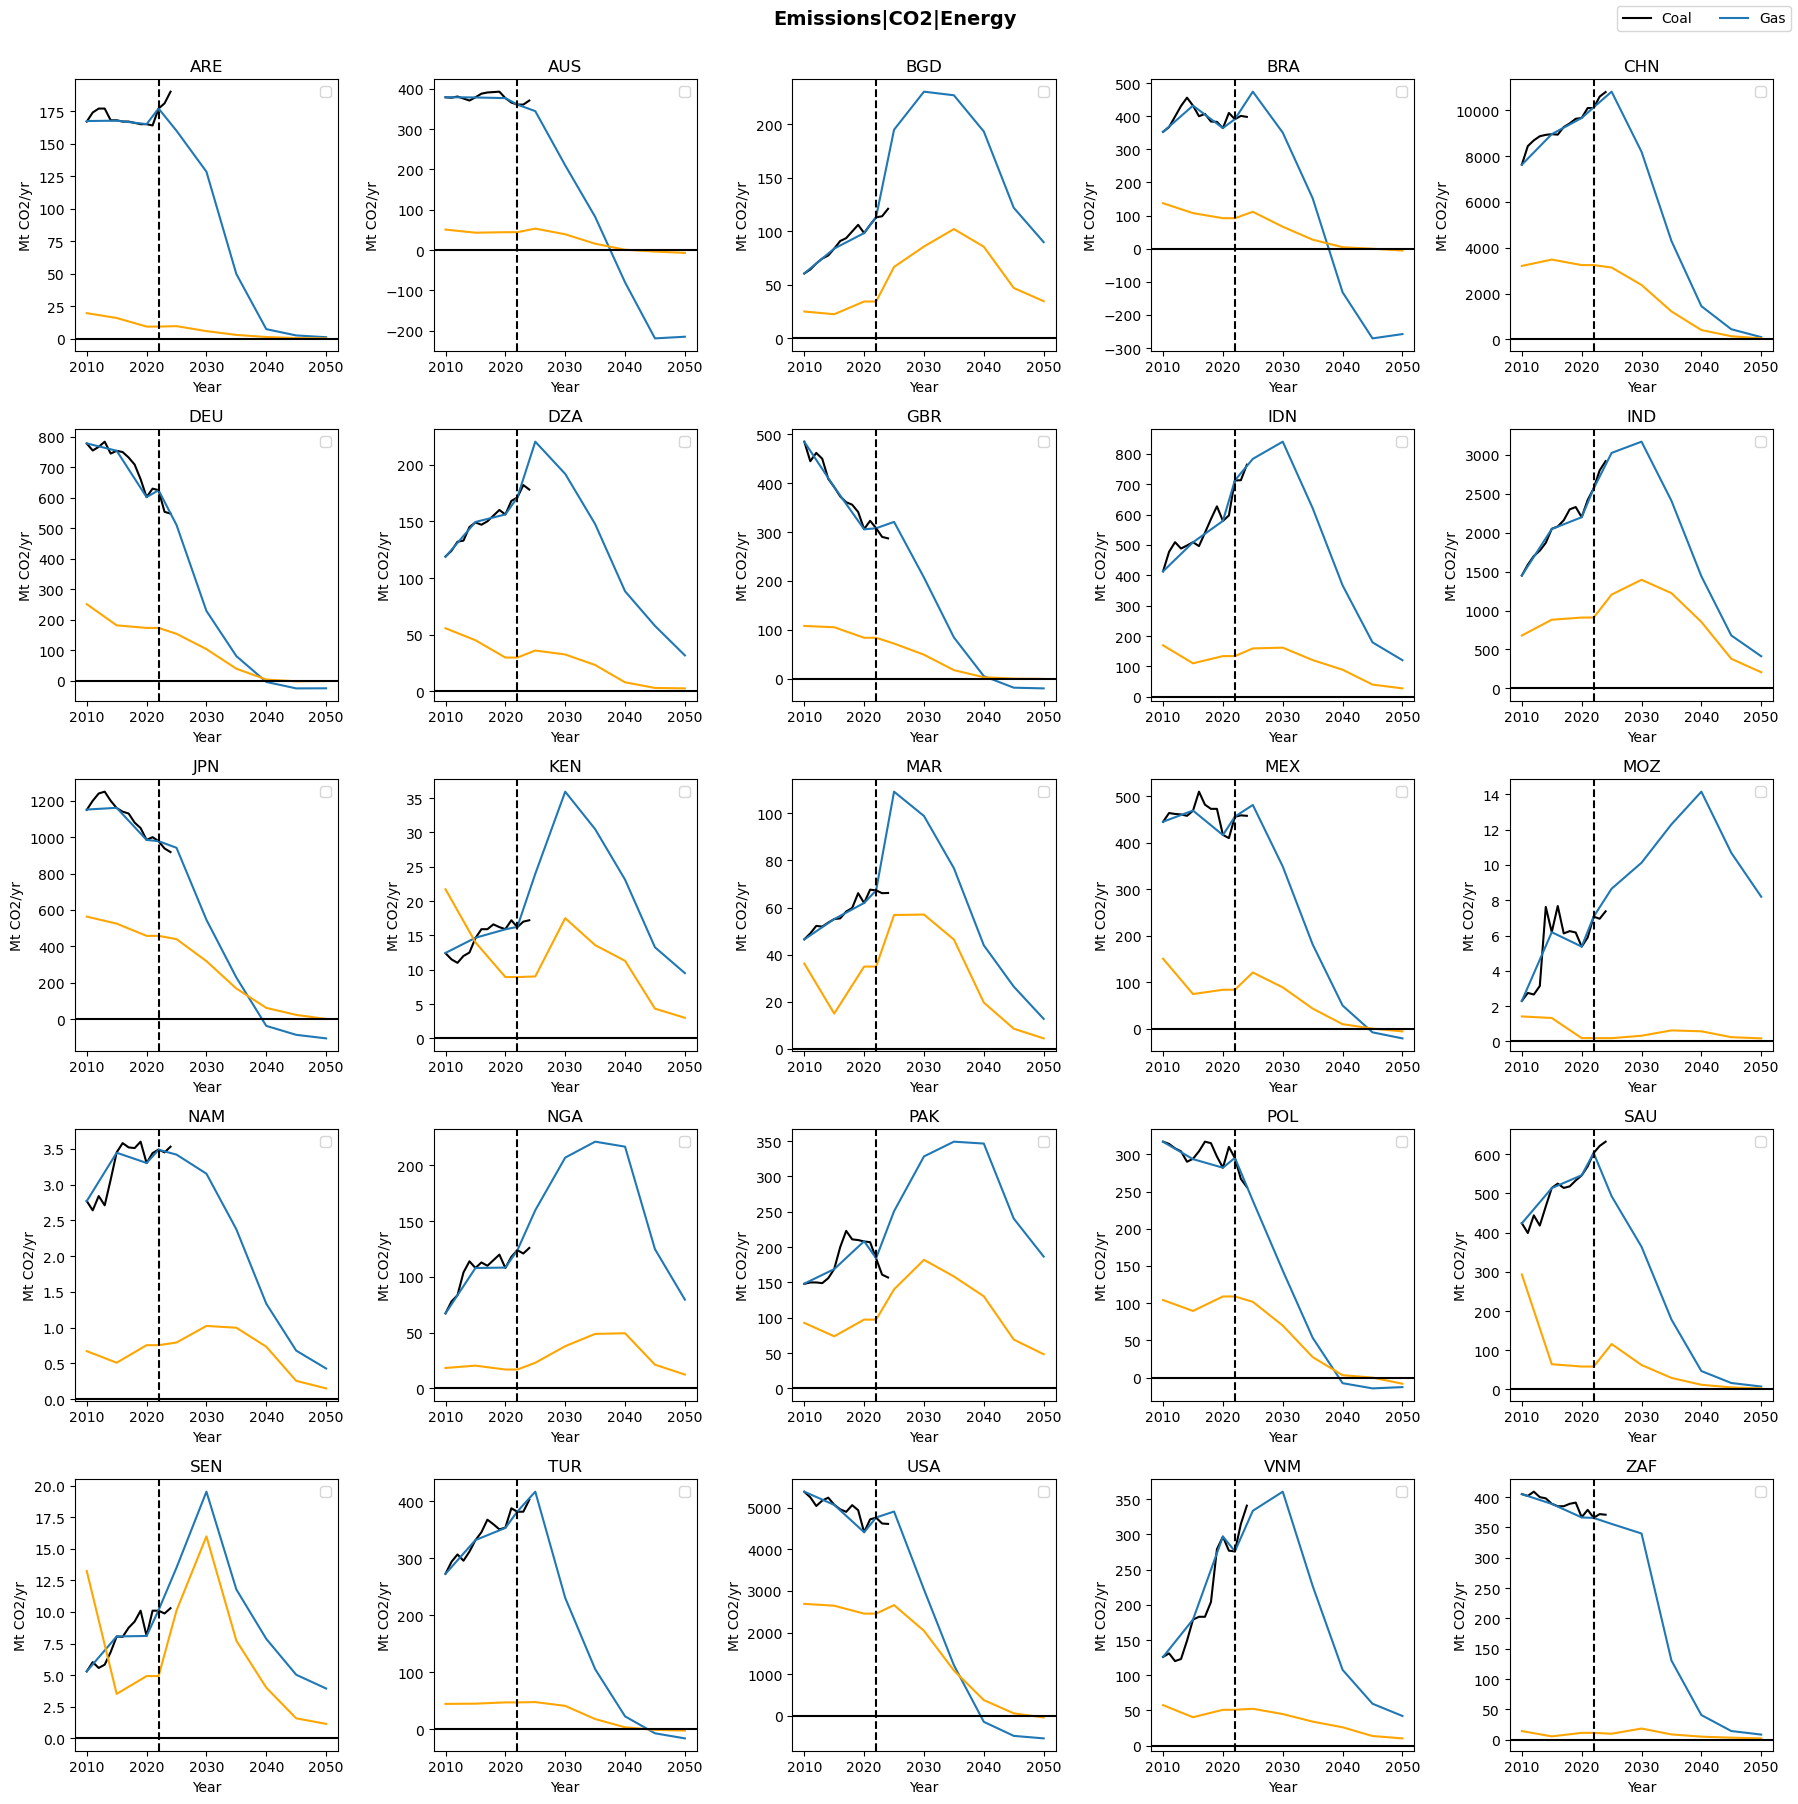

In [79]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy"

for count, ax in enumerate(axes.ravel()[:]):
    primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    dscale_emissions.aggregate('Emissions|CO2|Energy|Agg', ['Emissions|CO2|Energy|Demand|Industry',
 'Emissions|CO2|Energy|Demand|Residential and Commercial',
 'Emissions|CO2|Energy|Supply|Electricity|Oil',
 'Emissions|CO2|Energy|Demand|Transportation']).filter(region = IKEA_ISOS[count],year=range(2010,2051)).plot(ax=ax,color='orange', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

In [80]:
dscale_emissions.filter(variable = "Emissions|CO2*").variable

['Emissions|CO2',
 'Emissions|CO2|Energy',
 'Emissions|CO2|Energy|Demand|Industry',
 'Emissions|CO2|Energy|Demand|Residential and Commercial',
 'Emissions|CO2|Energy|Supply|Electricity|Oil',
 'Emissions|CO2|Industrial Processes',
 'Emissions|CO2|LULUCF Direct+Indirect',
 'Emissions|CO2|LULUCF Indirect',
 'Emissions|CO2|Energy|Demand|Transportation']

## Energy mix

In [108]:
dscale_results.check_aggregate("Final Energy|Transportation|Liquids", rtol = 1e-2).loc[isin(region = IKEA_ISOS, year = 2050)]

pyam.core - INFO: `Final Energy|Transportation|Liquids` - 2146 of 3860 rows are not aggregates of components


variable  \
model                 scenario region variable                            unit  year             
REMIND-MAgPIE 3.3-4.8 NPE-core BRA    Final Energy|Transportation|Liquids EJ/yr 2050    0.6111   
                               KEN    Final Energy|Transportation|Liquids EJ/yr 2050    0.0599   
                               MEX    Final Energy|Transportation|Liquids EJ/yr 2050    0.3454   
                               MOZ    Final Energy|Transportation|Liquids EJ/yr 2050    0.0479   
                               NAM    Final Energy|Transportation|Liquids EJ/yr 2050    0.0021   
                               NGA    Final Energy|Transportation|Liquids EJ/yr 2050    0.4095   
                               SEN    Final Energy|Transportation|Liquids EJ/yr 2050    0.0255   
                               TUR    Final Energy|Transportation|Liquids EJ/yr 2050    0.2185   
                               ZAF    Final Energy|Transportation|Liquids EJ/yr 2050    0.0323   

                                                                                      components  
model                 scenario region variable                            unit  year              
REMIND-MAgPIE 3.3-4.8 NPE-core BRA    Final Energy|Transportation|Liquids EJ/yr 2050      0.8868  
                               KEN    Final Energy|Transportation|Liquids EJ/yr 2050      0.0625  
                               MEX    Final Energy|Transportation|Liquids EJ/yr 2050      0.1796  
                               MOZ    Final Energy|Transportation|Liquids EJ/yr 2050      0.0493  
                               NAM    Final Energy|Transportation|Liquids EJ/yr 2050      0.0022  
                               NGA    Final Energy|Transportation|Liquids EJ/yr 2050      0.4279  
                               SEN    Final Energy|Transportation|Liquids EJ/yr 2050      0.0265  
                               TUR    Final Energy|Transportation|Liquids EJ/yr 2050      0.2257  
                               ZAF    Final Energy|Transportation|Liquids EJ/yr 2050      0.0339

In [113]:
dscale_results.filter(variable = "Final Energy|Industry|Solids*", region = "BRA").variable

['Final Energy|Industry|Solids',
 'Final Energy|Industry|Solids|Biomass',
 'Final Energy|Industry|Solids|Coal']

In [115]:
dscale_results.check_aggregate("Final Energy|Industry|Liquids", rtol = 1e-2).loc[isin(region = IKEA_ISOS, year = 2050)]

pyam.core - INFO: `Final Energy|Industry|Liquids` - 3519 of 3860 rows are not aggregates of components


variable  \
model                 scenario region variable                      unit  year             
REMIND-MAgPIE 3.3-4.8 NPE-core ARE    Final Energy|Industry|Liquids EJ/yr 2050    0.0394   
                               AUS    Final Energy|Industry|Liquids EJ/yr 2050    0.2513   
                               BGD    Final Energy|Industry|Liquids EJ/yr 2050    0.9623   
                               BRA    Final Energy|Industry|Liquids EJ/yr 2050    0.5030   
                               CHN    Final Energy|Industry|Liquids EJ/yr 2050    6.8926   
                               DEU    Final Energy|Industry|Liquids EJ/yr 2050    0.3459   
                               DZA    Final Energy|Industry|Liquids EJ/yr 2050    0.7933   
                               GBR    Final Energy|Industry|Liquids EJ/yr 2050    0.2885   
                               IDN    Final Energy|Industry|Liquids EJ/yr 2050    1.7193   
                               KEN    Final Energy|Industry|Liquids EJ/yr 2050    0.0708   
                               MAR    Final Energy|Industry|Liquids EJ/yr 2050    0.4918   
                               MEX    Final Energy|Industry|Liquids EJ/yr 2050    0.3079   
                               MOZ    Final Energy|Industry|Liquids EJ/yr 2050    0.0410   
                               NAM    Final Energy|Industry|Liquids EJ/yr 2050    0.0038   
                               NGA    Final Energy|Industry|Liquids EJ/yr 2050    0.4610   
                               PAK    Final Energy|Industry|Liquids EJ/yr 2050    2.0282   
                               POL    Final Energy|Industry|Liquids EJ/yr 2050    0.1457   
                               SAU    Final Energy|Industry|Liquids EJ/yr 2050    0.2574   
                               SEN    Final Energy|Industry|Liquids EJ/yr 2050    0.0277   
                               TUR    Final Energy|Industry|Liquids EJ/yr 2050    0.2465   
                               VNM    Final Energy|Industry|Liquids EJ/yr 2050    0.5432   
                               ZAF    Final Energy|Industry|Liquids EJ/yr 2050    0.0755   

                                                                                components  
model                 scenario region variable                      unit  year              
REMIND-MAgPIE 3.3-4.8 NPE-core ARE    Final Energy|Industry|Liquids EJ/yr 2050      0.0413  
                               AUS    Final Energy|Industry|Liquids EJ/yr 2050      0.2561  
                               BGD    Final Energy|Industry|Liquids EJ/yr 2050      1.3163  
                               BRA    Final Energy|Industry|Liquids EJ/yr 2050      0.7934  
                               CHN    Final Energy|Industry|Liquids EJ/yr 2050      7.1396  
                               DEU    Final Energy|Industry|Liquids EJ/yr 2050      0.2973  
                               DZA    Final Energy|Industry|Liquids EJ/yr 2050      0.7606  
                               GBR    Final Energy|Industry|Liquids EJ/yr 2050      0.2815  
                               IDN    Final Energy|Industry|Liquids EJ/yr 2050      1.9340  
                               KEN    Final Energy|Industry|Liquids EJ/yr 2050      0.0983  
                               MAR    Final Energy|Industry|Liquids EJ/yr 2050      0.5646  
                               MEX    Final Energy|Industry|Liquids EJ/yr 2050      0.1705  
                               MOZ    Final Energy|Industry|Liquids EJ/yr 2050      0.0598  
                               NAM    Final Energy|Industry|Liquids EJ/yr 2050      0.0040  
                               NGA    Final Energy|Industry|Liquids EJ/yr 2050      0.4763  
                               PAK    Final Energy|Industry|Liquids EJ/yr 2050      2.5896  
                               POL    Final Energy|Industry|Liquids EJ/yr 2050      0.1639  
                               SAU    Final Energy|Industry|Liquids EJ/yr 2050      0.2949  
           

In [122]:
input_data_harm

NameError: name 'input_data_harm' is not defined

KeyboardInterrupt: 

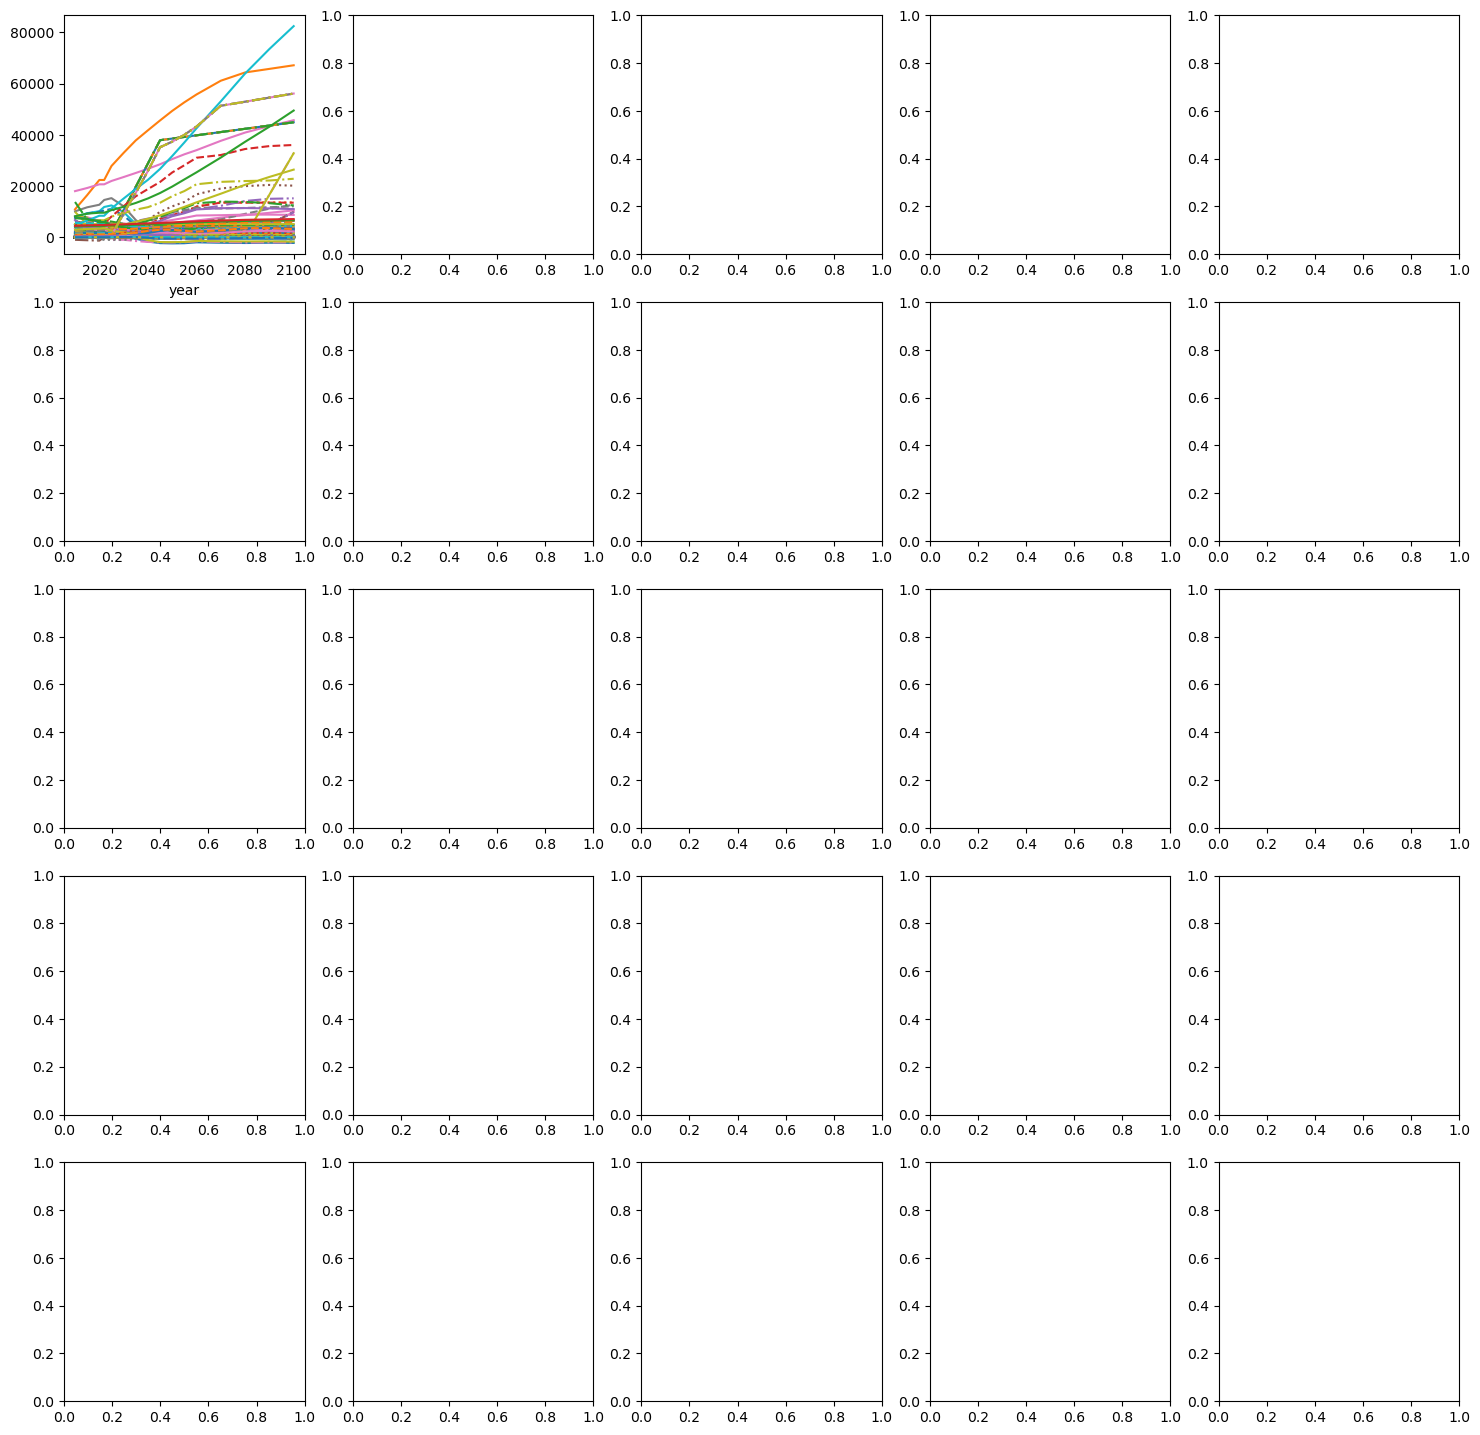

In [120]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Final Energy|Transportation|Liquids*"

for count, ax in enumerate(axes.ravel()[:]):
    macro_df.filter(scenario='NPE-core',region="LAM",variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    remind
    # dscale_results.filter(scenario='NPE-core',region=,variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")

    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])
    ax.set_xlabel("")

ax.legend(bbox_to_anchor=(1,6.5))

f.suptitle(vars,fontsize=12,fontweight='bold', y=1)
# f.legend(['Liquids','Biomass', "Electricity", "Oil"],ncols=2)
plt.tight_layout()

/var/folders/m8/48479kf16gl9rvhblbkv6myw0000gp/T/ipykernel_48327/3001616887.py:18: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


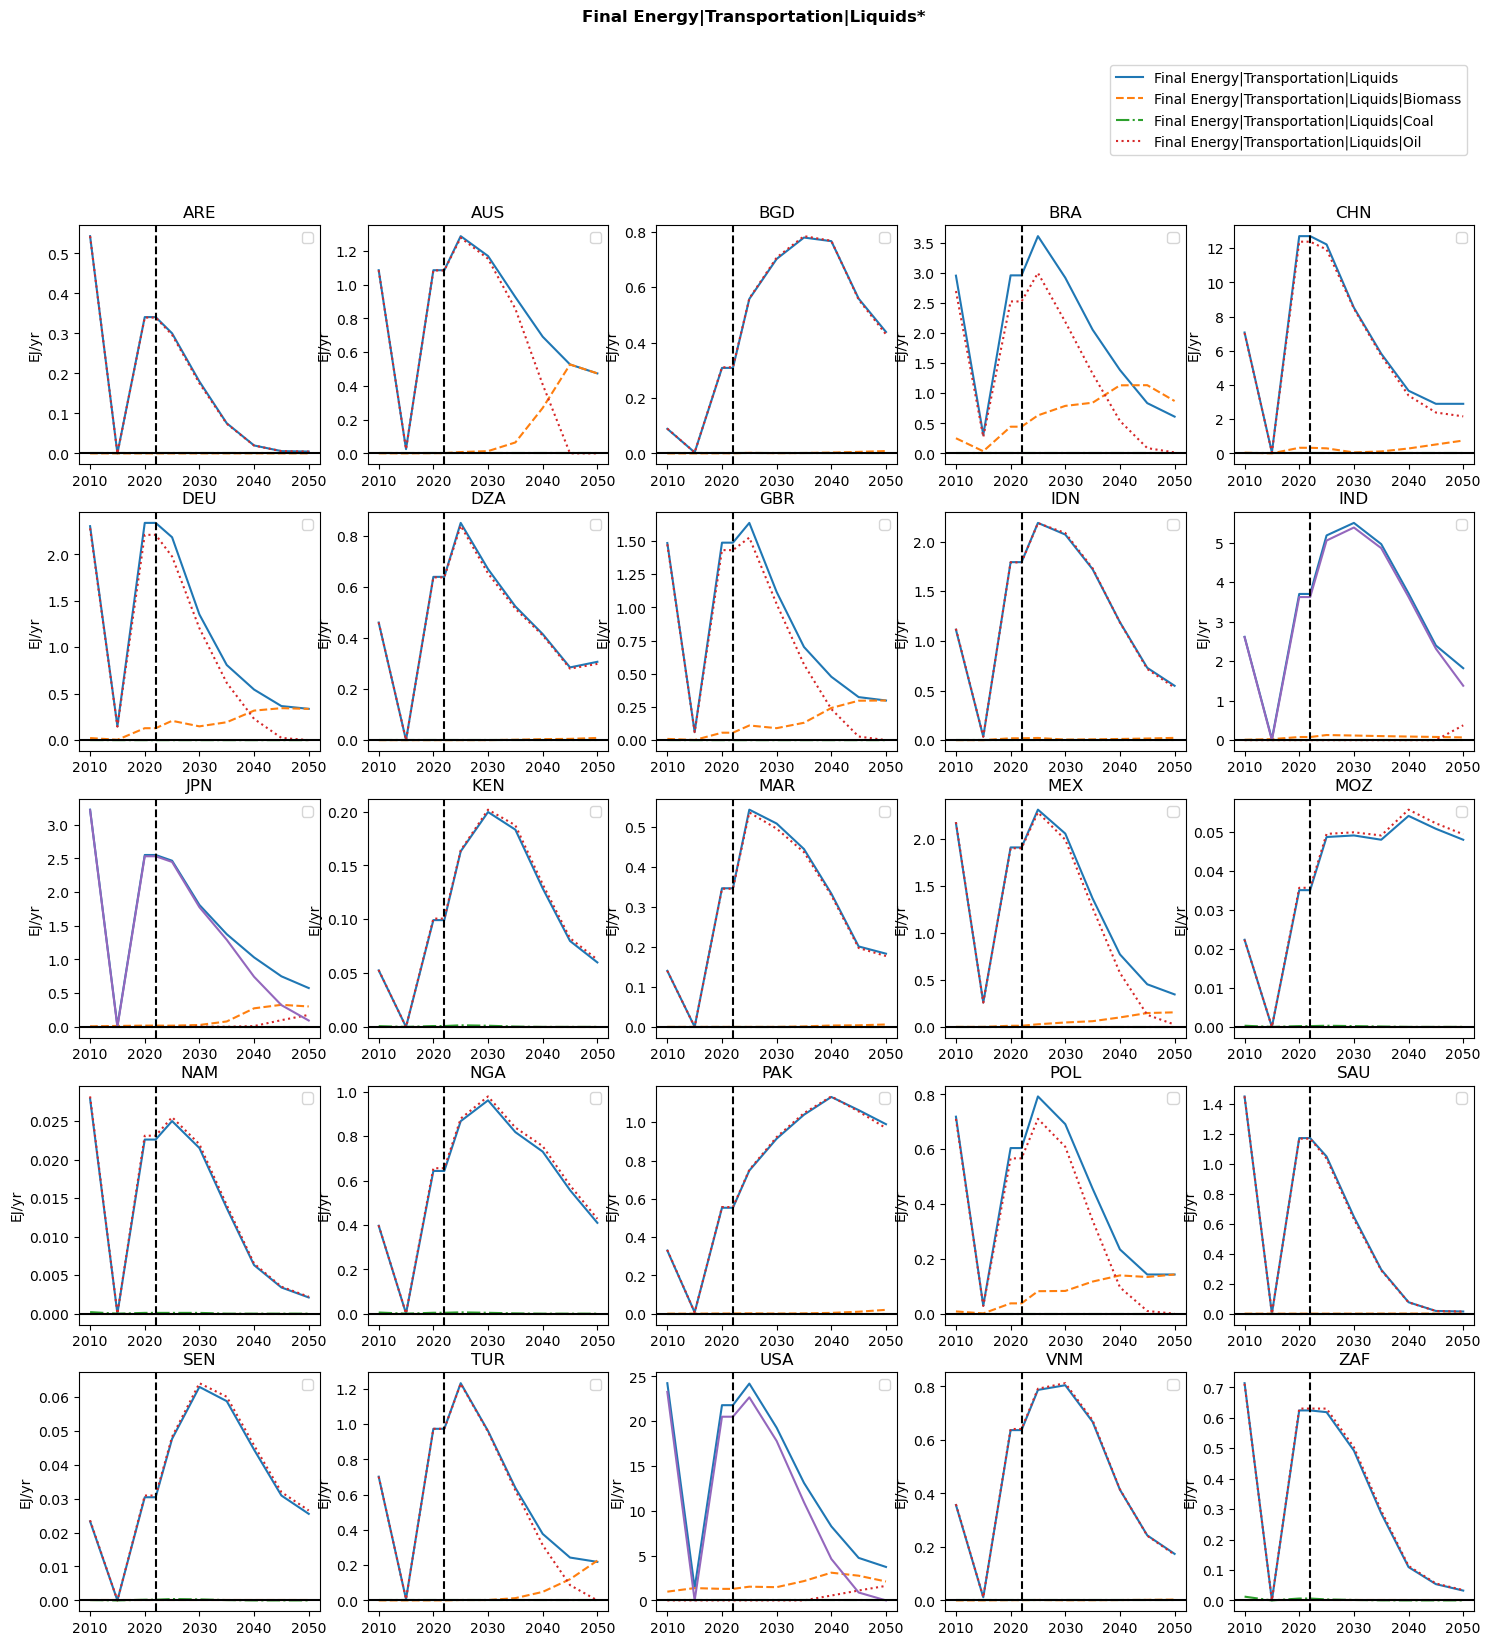

In [104]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Final Energy|Transportation|Liquids*"

for count, ax in enumerate(axes.ravel()[:]):
    # primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")

    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])
    ax.set_xlabel("")

ax.legend(bbox_to_anchor=(1,6.5))

f.suptitle(vars,fontsize=12,fontweight='bold', y=1)
# f.legend(['Liquids','Biomass', "Electricity", "Oil"],ncols=2)
plt.tight_layout()

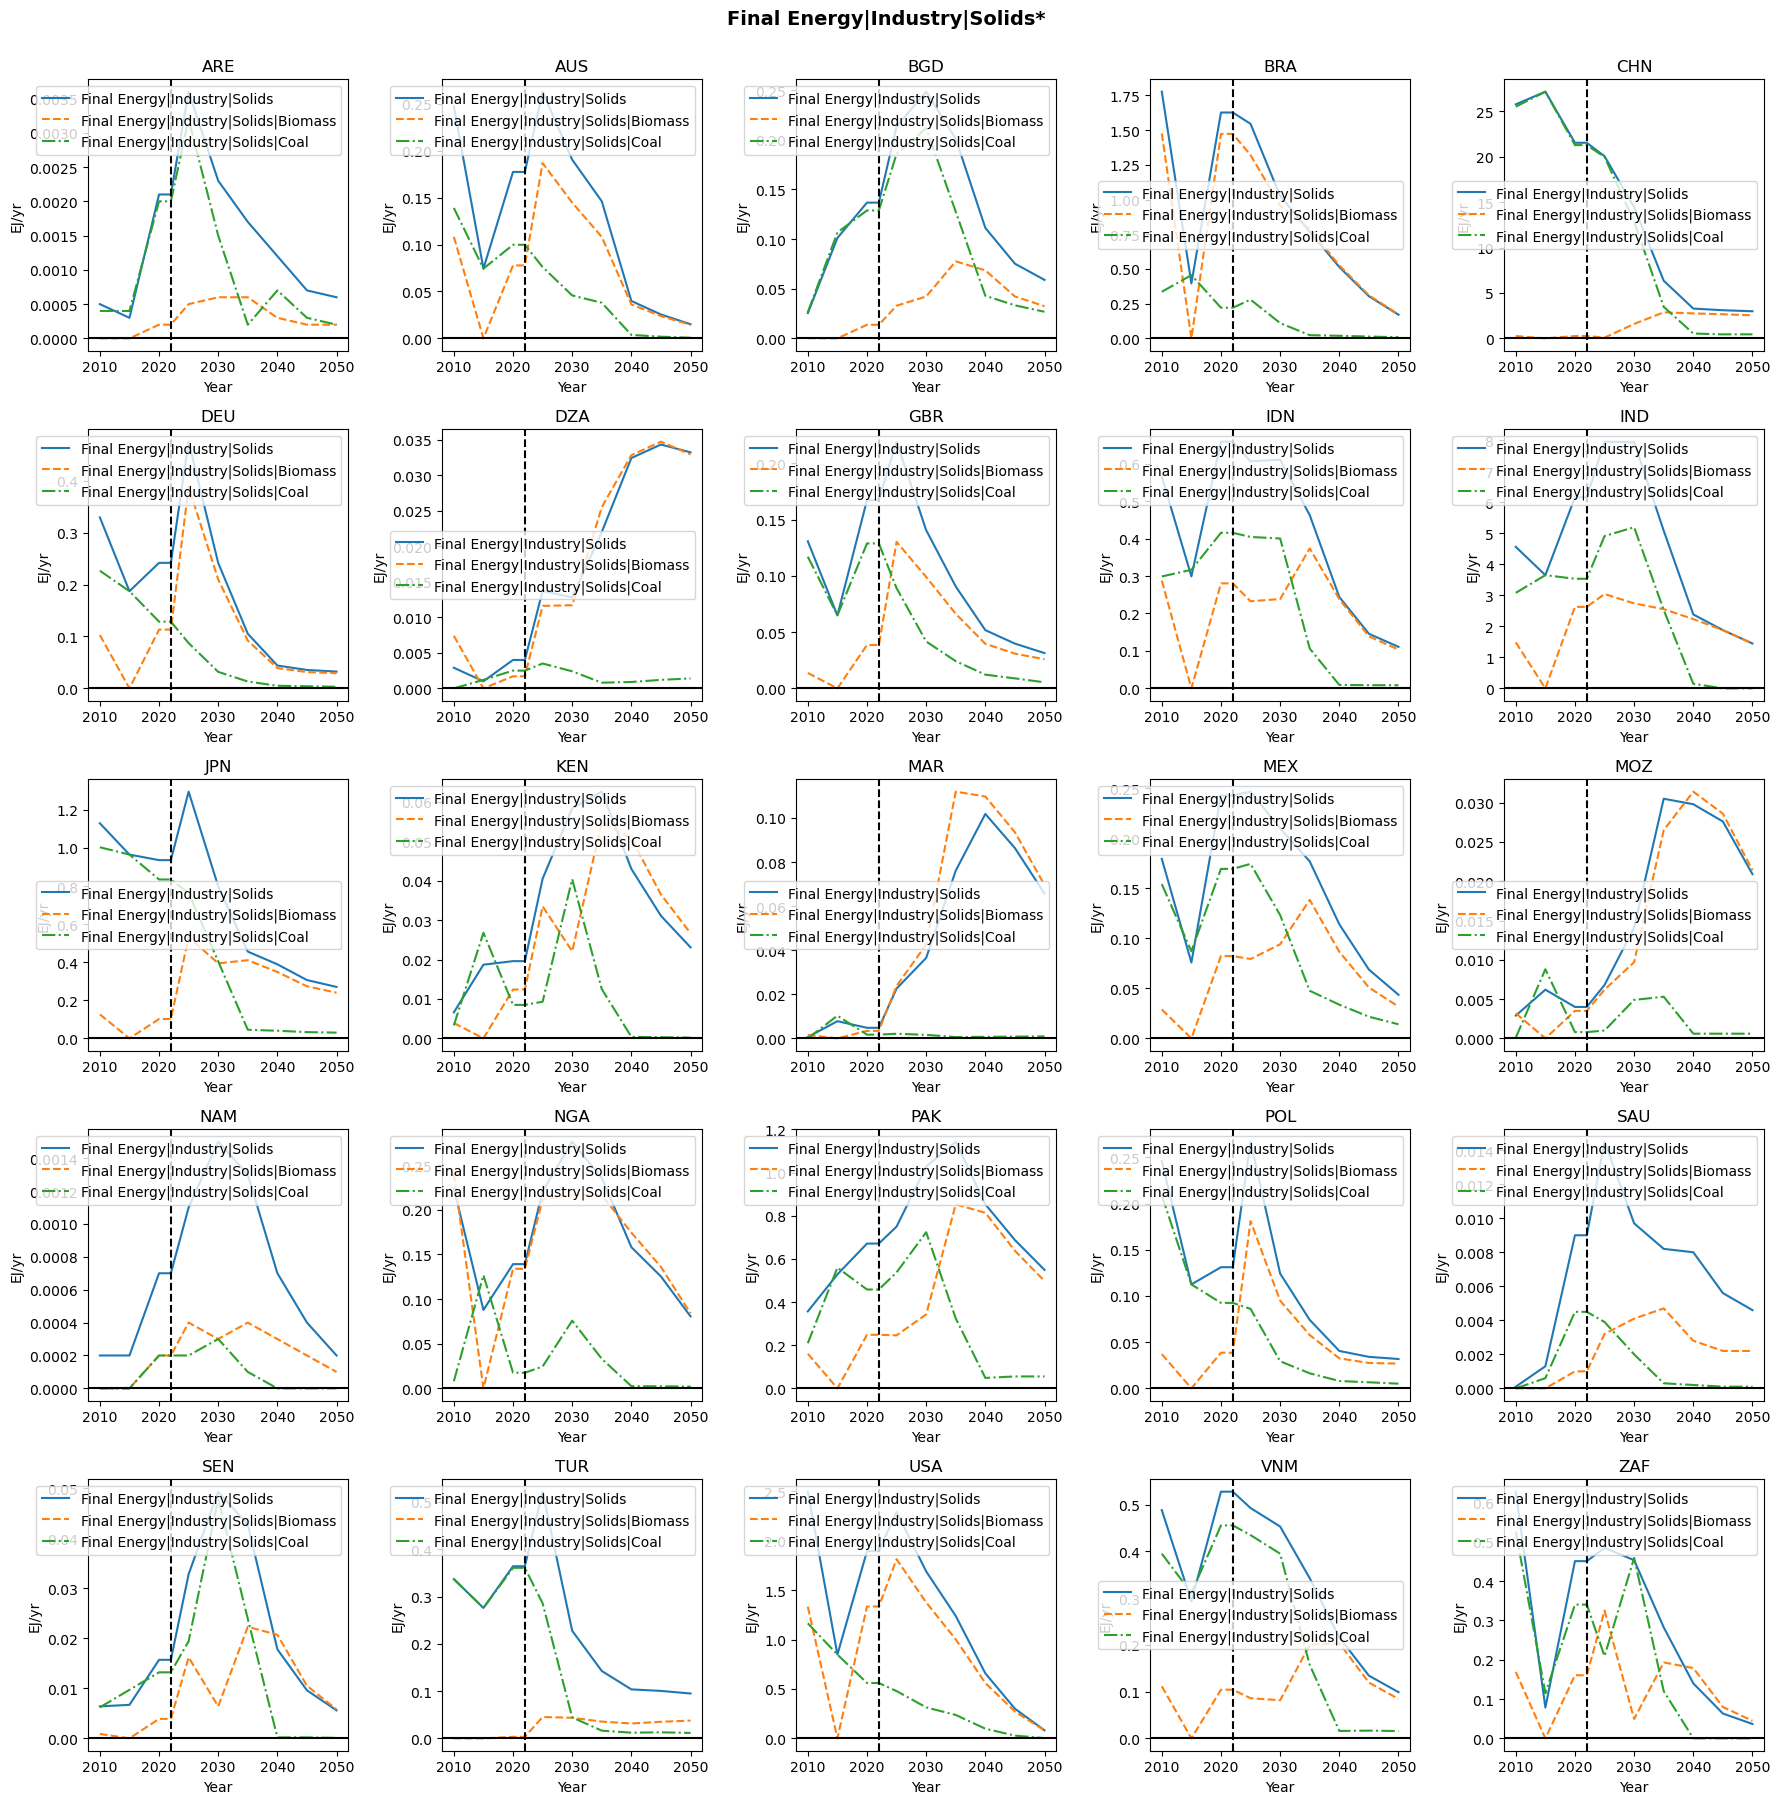

In [114]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Final Energy|Industry|Solids*"

for count, ax in enumerate(axes.ravel()[:]):
    # primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")

    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend()


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
# f.legend(['Liquids','Biomass', "Electricity", "Oil"],ncols=2)
plt.tight_layout()

In [90]:
iea_energy

<class 'pyam.core.IamDataFrame'>
Index:
 * model    : IEA_WEB_DETAILED_2025 (1)
 * scenario : Historic (1)
Timeseries data coordinates:
   region   : AGO, ALB, ANT, ARE, ARG, ARM, AUS, AUT, AZE, BEL, ... ZWE (152)
   variable : Final Energy, Final Energy|AFOFI, ... Secondary Energy|Heat|Wind (186)
   unit     : EJ / yr, TWh / yr (2)
   year     : 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, ... 2024 (65)
Meta indicators:
   exclude (bool) False (1)
   source (object) IEA_WEB_DETAILED_2025 (1)
   pathway (object) Historic (1)

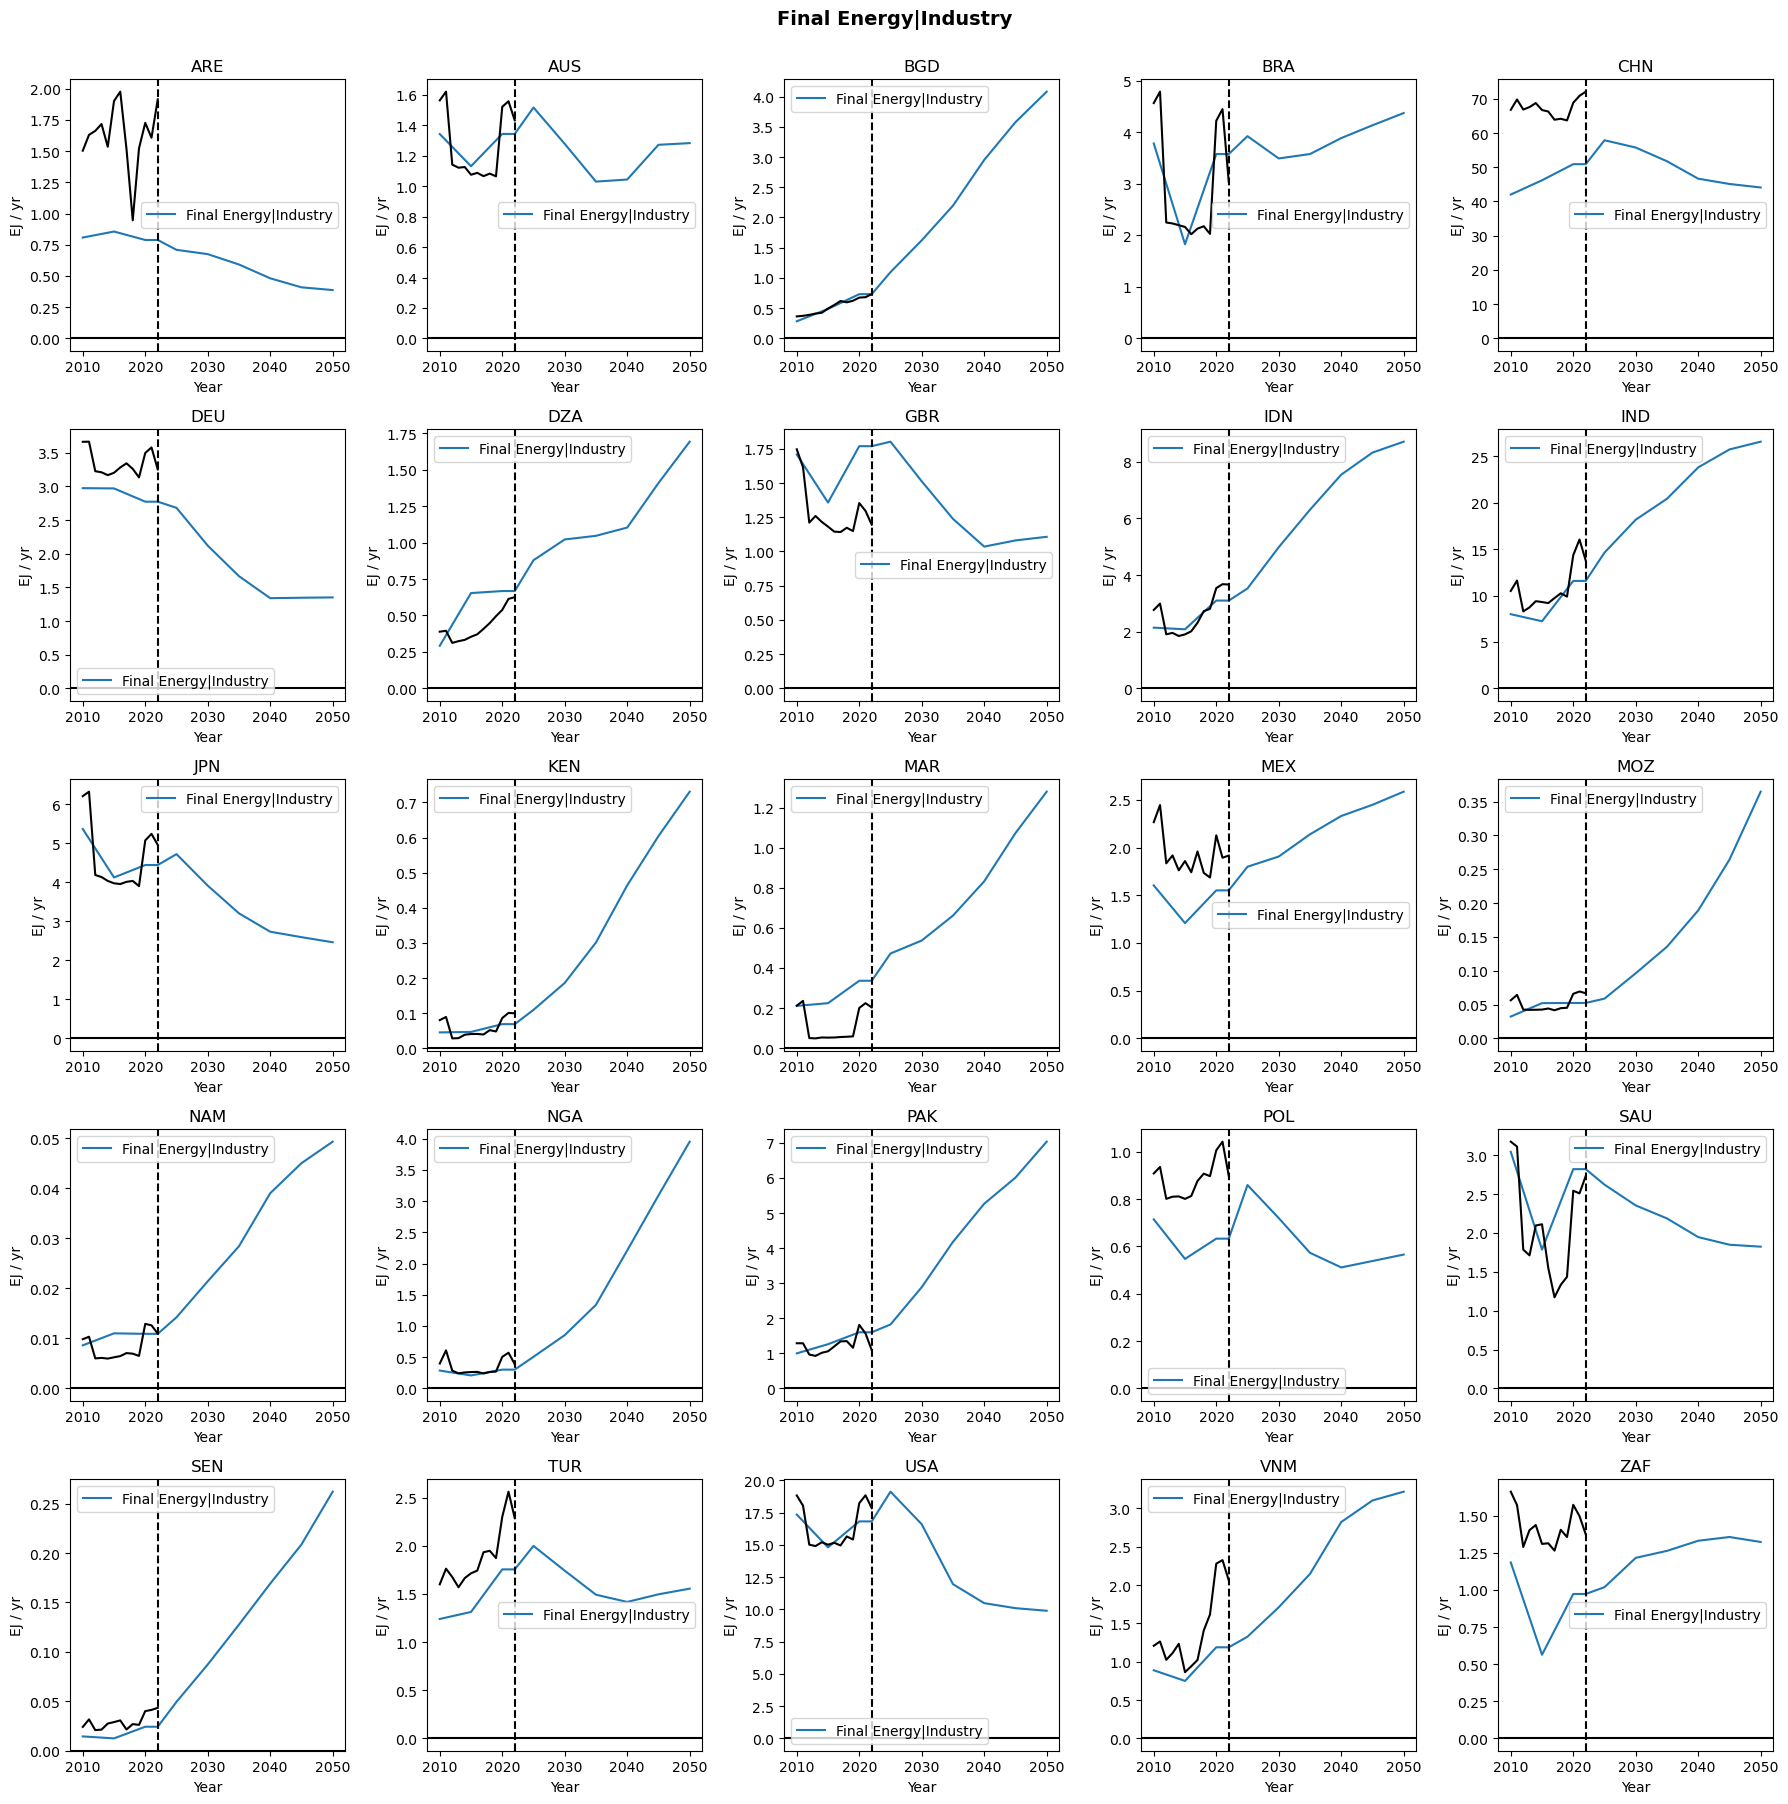

In [93]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Final Energy|Industry"

for count, ax in enumerate(axes.ravel()[:]):
    # primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    iea_energy.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2023)).plot(ax=ax, color = "k")

    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend()


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
# f.legend(['Liquids','Biomass', "Electricity", "Oil"],ncols=2)
plt.tight_layout()

# Comparing with MDPs

In [38]:
mdps_remind=mdps_remind.rename(variable = {
    "2ºC": "Emissions|Kyoto Gases (incl. indirect AFOLU)", 
    "1.5ºC": "Emissions|Kyoto Gases (incl. indirect AFOLU)"
})

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is 

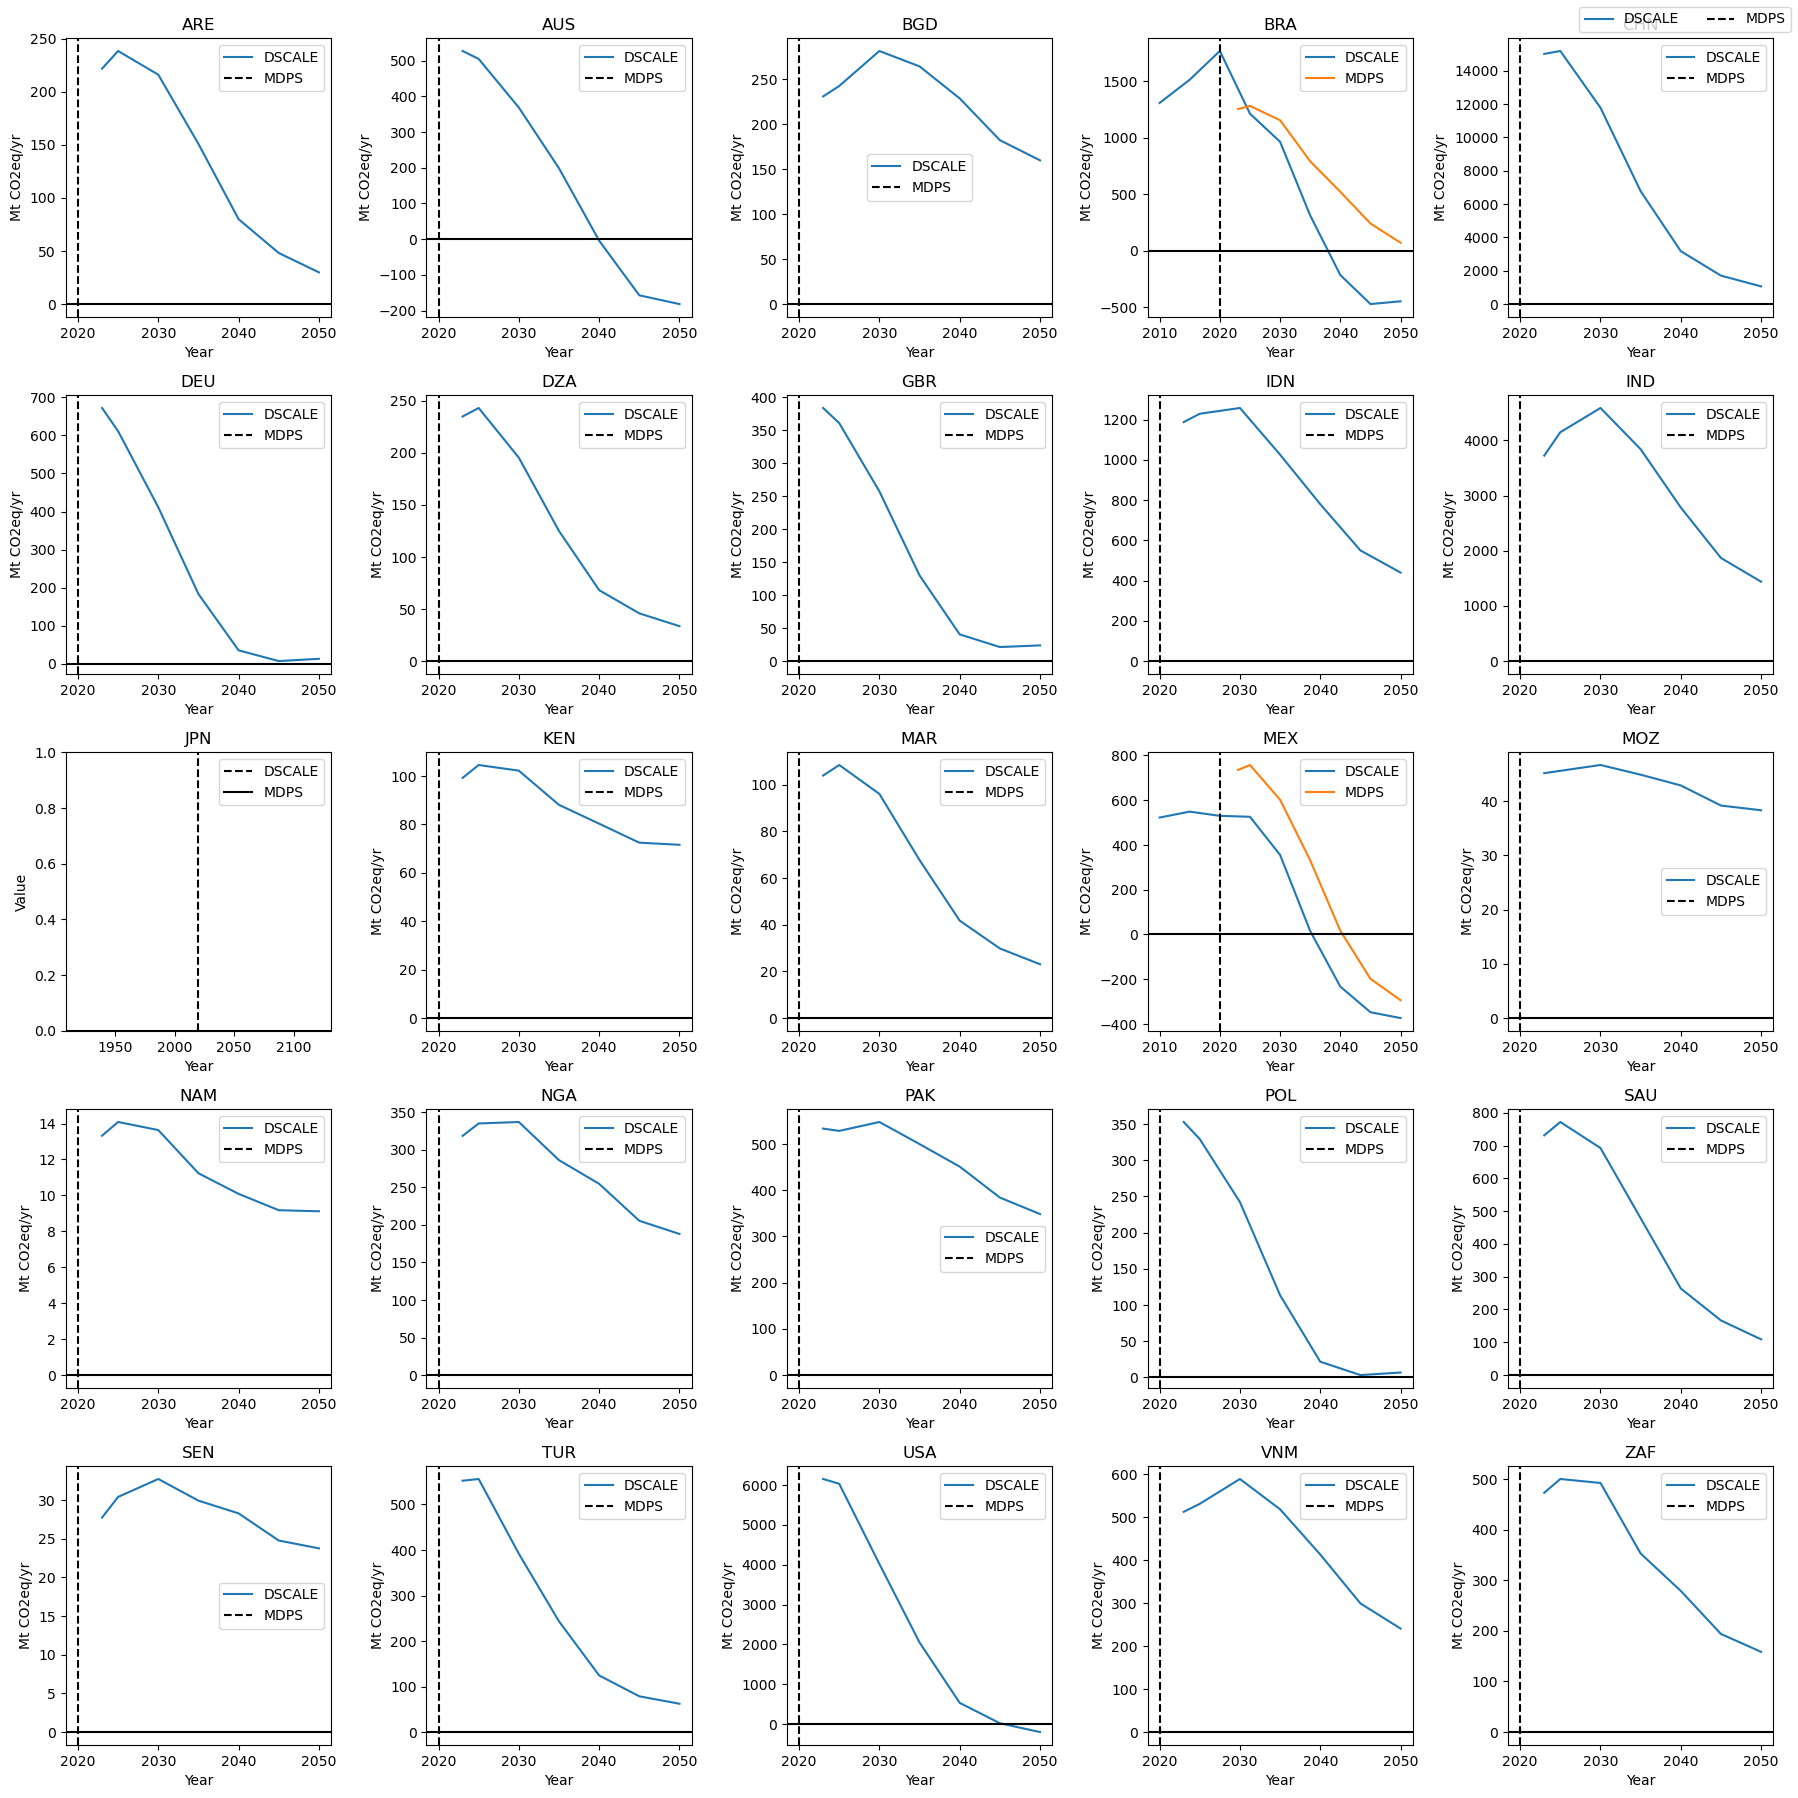

In [47]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|Kyoto Gases (incl. indirect AFOLU)"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable", label="DSCALE")
    mdps_remind.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable", label="MDPS")
    # primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2020,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend(['DSCALE','MDPS'])


# f.suptitle('Coal and gas power sector transition',fontsize=14,fontweight='bold', y=1)
f.legend(['DSCALE','MDPS'],ncols=2)
plt.tight_layout()